## Install Libraries

In [1]:
!pip install -q kagglehub[pandas-datasets]

## Load Dataset

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jiashenliu/515k-hotel-reviews-data-in-europe",
    "Hotel_Reviews.csv"
)



/tmp/ipykernel_2427/93763039.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 45.1M/45.1M [00:00<00:00, 55.5MB/s]

Extracting zip of Hotel_Reviews.csv...


## Display First Few Rows

In [3]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


## Check Dataset Shape

In [4]:
print(df.shape)


(515738, 17)


## Display Column Names

In [5]:
print(df.columns)

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')


## Get Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

## Check for Missing Values

In [7]:
print(df.isnull().sum())

Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64


## Check for Duplicate Rows

In [8]:
print(df.duplicated().sum())

526


## Handle Duplicate Rows

In [9]:
df = df.drop_duplicates()

print(df.shape)

(515212, 17)


## Select Relevant Columns

In [10]:
df = df[[
    "Hotel_Name",
    "Positive_Review",
    "Negative_Review",
    "Reviewer_Score"
]]

df.head()

,Hotel_Name,Positive_Review,Negative_Review,Reviewer_Score
0,Hotel Arena,Only the park outside of the hotel was beauti...,I am so angry that i made this post available...,2.9
1,Hotel Arena,No real complaints the hotel was great great ...,No Negative,7.5
2,Hotel Arena,Location was good and staff were ok It is cut...,Rooms are nice but for elderly a bit difficul...,7.1
3,Hotel Arena,Great location in nice surroundings the bar a...,My room was dirty and I was afraid to walk ba...,3.8
4,Hotel Arena,Amazing location and building Romantic setting,You When I booked with your company on line y...,6.7


## Combine Positive and Negative Reviews

In [11]:
df["Review"] = df["Positive_Review"] + " " + df["Negative_Review"]

## Prepare Data for Sentiment Analysis

In [12]:
df = df[["Review","Reviewer_Score"]]

df.head()

,Review,Reviewer_Score
0,Only the park outside of the hotel was beauti...,2.9
1,No real complaints the hotel was great great ...,7.5
2,Location was good and staff were ok It is cut...,7.1
3,Great location in nice surroundings the bar a...,3.8
4,Amazing location and building Romantic settin...,6.7


## Categorize Sentiment Scores

In [13]:
def sentiment(score):
    if score >= 8:
        return "Positive"
    elif score >= 5:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Reviewer_Score"].apply(sentiment)

## Display Sentiment Distribution

In [14]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    335355
Neutral     157625
Negative     22232
Name: count, dtype: int64


## Visualize Sentiment Distribution

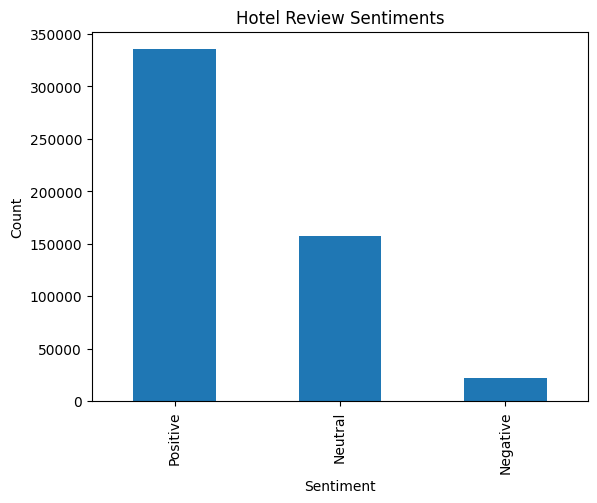

In [15]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Hotel Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Clean Review Text

In [16]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text)
    return text

df["Review"] = df["Review"].apply(clean)

## Split Data into Training and Testing Sets

In [17]:
from sklearn.model_selection import train_test_split

X = df["Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Build and Train Model

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier', MultinomialNB())])

## Make Predictions

In [19]:
y_pred = model.predict(X_test)

## Import Evaluation Metrics

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Evaluate Model Accuracy

In [21]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.7311025494211154


## Display Classification Report

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.25      0.00      0.00      4446
     Neutral       0.61      0.41      0.49     31470
    Positive       0.76      0.93      0.84     67127

    accuracy                           0.73    103043
   macro avg       0.54      0.45      0.44    103043
weighted avg       0.69      0.73      0.70    103043



## Display Confusion Matrix

In [23]:
print(confusion_matrix(y_test, y_pred))

[[    4  3446   996]
 [    3 12805 18662]
 [    9  4592 62526]]


## Test Model with Review

In [24]:
review = [
    "The room was very clean and the staff were extremely friendly."
]

print(model.predict(review))

['Positive']


In [25]:
review = [
    "Dirty bathroom, good food and rude staff."
]

print(model.predict(review))

['Neutral']
